# Анализ ассортимента интернет-магазина (ABC/XYZ-анализ)

**Задача:** оценить структуру ассортимента британского интернет-магазина подарков и товаров для дома, выделить группы SKU по экономической значимости (ABC) и вариативности спроса (XYZ), сформировать обоснованный список кандидатов на сокращение и оценить потенциальный эффект.

**Источник данных:** [UCI Machine Learning Repository — Online Retail II](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)

**Датасет** содержит транзакционные данные британского интернет-магазина за период с 01.12.2009 по 09.12.2011.

**Признаки:**
- `InvoiceNo` — номер счета (операции). Начинается с 'C' для отмен.
- `StockCode` — уникальный код товара (SKU).
- `Description` — название товара.
- `Quantity` — количество единиц товара в операции.
- `InvoiceDate` — дата и время операции.
- `UnitPrice` — цена за единицу товара в фунтах стерлингов.
- `CustomerID` — идентификатор клиента.
- `Country` — страна клиента.

## Импорт библиотек и настройки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42

## Загрузка данных

In [2]:
DATA_PATH = 'online_retail.csv'
df_raw = pd.read_csv(DATA_PATH)

print(f'Размер исходной таблицы: {df_raw.shape}')
print(f'Столбцы: {list(df_raw.columns)}')
df_raw.head()

Размер исходной таблицы: (1067371, 8)
Столбцы: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

Загружено **1 067 371 строк** и 8 столбцов. Названия полей отличаются от описания в ТЗ (`Invoice` вместо `InvoiceNo`, `Price` вместо `UnitPrice`, `Customer ID` вместо `CustomerID`), поэтому далее в коде используются фактические имена.

</div>

## Первичное знакомство с данными

In [3]:
print('ИНФОРМАЦИЯ О ТИПАХ И ПРОПУСКАХ')
df_raw.info()

ИНФОРМАЦИЯ О ТИПАХ И ПРОПУСКАХ
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [4]:
print('ПРОПУСКИ ПО СТОЛБЦАМ')
missing = df_raw.isna().sum().to_frame('missing_count')
missing['missing_pct'] = (missing['missing_count'] / len(df_raw) * 100).round(2)
print(missing)

ПРОПУСКИ ПО СТОЛБЦАМ
             missing_count  missing_pct
Invoice                  0         0.00
StockCode                0         0.00
Description           4382         0.41
Quantity                 0         0.00
InvoiceDate              0         0.00
Price                    0         0.00
Customer ID         243007        22.77
Country                  0         0.00


In [5]:
print('ВРЕМЕННОЙ ДИАПАЗОН')
print(f"Минимум: {df_raw['InvoiceDate'].min()}")
print(f"Максимум: {df_raw['InvoiceDate'].max()}")

ВРЕМЕННОЙ ДИАПАЗОН
Минимум: 2009-12-01 07:45:00
Максимум: 2011-12-09 12:50:00


In [6]:
print('ДУБЛИКАТЫ')
print(f'Полных дубликатов: {df_raw.duplicated().sum()}')

ДУБЛИКАТЫ
Полных дубликатов: 34335


In [7]:
print('ПРИМЕРЫ ПОЛНЫХ ДУБЛИКАТОВ')
dupes = df_raw[df_raw.duplicated(keep=False)].sort_values(['Invoice', 'StockCode'])
print(f'Всего строк, участвующих в дубликатах: {len(dupes)}')
print(f'Уникальных Invoice в дубликатах: {dupes["Invoice"].nunique()}')
print('\nТОП-5 Invoice по числу дублирующихся строк:')
print(dupes['Invoice'].value_counts().head())
print('\nПример одной группы дубликатов:')
first_inv = dupes['Invoice'].iloc[0]
print(dupes[dupes['Invoice'] == first_inv].to_string(index=False))

ПРИМЕРЫ ПОЛНЫХ ДУБЛИКАТОВ
Всего строк, участвующих в дубликатах: 67242
Уникальных Invoice в дубликатах: 5391

ТОП-5 Invoice по числу дублирующихся строк:
Invoice
537434    1350
538071    1304
537638    1202
537237    1194
536876    1186
Name: count, dtype: int64

Пример одной группы дубликатов:
Invoice StockCode                       Description  Quantity         InvoiceDate  Price  Customer ID        Country
 489517     21491   SET OF THREE VINTAGE GIFT WRAPS         1 2009-12-01 11:34:00   1.95    16,329.00 United Kingdom
 489517     21491   SET OF THREE VINTAGE GIFT WRAPS         1 2009-12-01 11:34:00   1.95    16,329.00 United Kingdom
 489517     21821  GLITTER STAR GARLAND WITH BELLS          1 2009-12-01 11:34:00   3.75    16,329.00 United Kingdom
 489517     21821  GLITTER STAR GARLAND WITH BELLS          1 2009-12-01 11:34:00   3.75    16,329.00 United Kingdom
 489517     21912          VINTAGE SNAKES & LADDERS         1 2009-12-01 11:34:00   3.75    16,329.00 United Kingdom
 4

In [8]:
print('УНИКАЛЬНЫЕ ЗНАЧЕНИЯ КЛЮЧЕВЫХ ПОЛЕЙ')
print(f"Уникальных StockCode: {df_raw['StockCode'].nunique()}")
print(f"Уникальных Invoice: {df_raw['Invoice'].nunique()}")
print(f"Уникальных Customer ID: {df_raw['Customer ID'].nunique()}")

УНИКАЛЬНЫЕ ЗНАЧЕНИЯ КЛЮЧЕВЫХ ПОЛЕЙ
Уникальных StockCode: 5305
Уникальных Invoice: 53628
Уникальных Customer ID: 5942


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

- **Пропуски:** В столбце `Customer ID` отсутствует 22.8% значений, что допустимо для ABC/XYZ-анализа. Пропуски в `Description` (0.4%) будут заполнены заглушкой.
- **Дубликаты:** Обнаружено 34 335 полных дубликатов, которые необходимо удалить для предотвращения искажения выручки.
- **Типы данных:** Столбец `InvoiceDate` требует преобразования в формат `datetime`. Остальные типы данных корректны.
- **Период:** Данные охватывают период с 01.12.2009 по 09.12.2011.

</div>

## Исследование аномалий

In [9]:
print('ОТМЕНЫ (Invoice начинается с "C")')
df_raw['IsCancelled'] = df_raw['Invoice'].astype(str).str.startswith('C')
print(f"Отмененных строк: {df_raw['IsCancelled'].sum()} "
      f"({df_raw['IsCancelled'].mean()*100:.2f}%)")

ОТМЕНЫ (Invoice начинается с "C")
Отмененных строк: 19494 (1.83%)


In [10]:
df_raw['InvoiceStr'] = df_raw['Invoice'].astype(str)
df_raw['InvoiceClean'] = df_raw['InvoiceStr'].str.lstrip('C')

cancelled_ids = set(df_raw.loc[df_raw['IsCancelled'], 'InvoiceClean'].unique())
regular_ids = set(df_raw.loc[~df_raw['IsCancelled'], 'InvoiceClean'].unique())

paired_ids = cancelled_ids & regular_ids
only_cancelled = cancelled_ids - regular_ids
only_regular = regular_ids - cancelled_ids

print(f'\nУникальных C-счетов:                 {len(cancelled_ids)}')
print(f'  из них имеют пару без "C":         {len(paired_ids)}')
print(f'  только C (нет обычного двойника):  {len(only_cancelled)}')
print(f'\nВсего строк в парных счетах (C + обычный): '
      f'{df_raw[df_raw["InvoiceClean"].isin(paired_ids)].shape[0]}')

# --- Сравнение: пара строк с "C" и без ---
sample_ids = list(paired_ids)[:3]
print('\n--- Примеры парных счетов (C и без C) ---')
for inv in sample_ids:
    pair = df_raw[df_raw['InvoiceClean'] == inv].sort_values('IsCancelled')
    print(f'\nInvoiceClean = {inv}:')
    cols = ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']
    print(pair[cols].head(6).to_string(index=False))


Уникальных C-счетов:                 8292
  из них имеют пару без "C":         0
  только C (нет обычного двойника):  8292

Всего строк в парных счетах (C + обычный): 0

--- Примеры парных счетов (C и без C) ---


In [11]:
print('РАСПРЕДЕЛЕНИЕ ПОЗИЦИЙ В ОДНОМ C-СЧЁТЕ')
cancelled_df = df_raw[df_raw['IsCancelled']]
lines_per_cancel = cancelled_df.groupby('Invoice').size()
print(lines_per_cancel.describe())
print(f'\nОднопозиционные возвраты: {(lines_per_cancel == 1).sum()} '
      f'({(lines_per_cancel == 1).mean()*100:.1f}%)')
print(f'Возвраты с 5+ позициями:  {(lines_per_cancel >= 5).sum()} '
      f'({(lines_per_cancel >= 5).mean()*100:.1f}%)')
print('\nТОП-3 C-счёта по числу позиций:')
top_cancels = lines_per_cancel.nlargest(3).index
for inv in top_cancels:
    sub = cancelled_df[cancelled_df['Invoice'] == inv]
    print(f'\n{inv}: {len(sub)} позиций, суммарный Quantity = {sub["Quantity"].sum()}')
    print(sub[['StockCode', 'Description', 'Quantity', 'Price']].head(5).to_string(index=False))

РАСПРЕДЕЛЕНИЕ ПОЗИЦИЙ В ОДНОМ C-СЧЁТЕ
count   8,292.00
mean        2.35
std         3.49
min         1.00
25%         1.00
50%         1.00
75%         2.00
max       101.00
dtype: float64

Однопозиционные возвраты: 4617 (55.7%)
Возвраты с 5+ позициями:  773 (9.3%)

ТОП-3 C-счёта по числу позиций:

C570867: 101 позиций, суммарный Quantity = -1228
StockCode                     Description  Quantity  Price
    23290         SPACEBOY CHILDRENS BOWL        -8   1.25
    23289       DOLLY GIRL CHILDRENS BOWL        -8   1.25
    23256     CHILDRENS CUTLERY SPACEBOY         -4   4.15
    23255 CHILDRENS CUTLERY CIRCUS PARADE        -4   4.15
    23254   CHILDRENS CUTLERY DOLLY GIRL         -4   4.15

C560540: 57 позиций, суммарный Quantity = -97
StockCode                         Description  Quantity  Price
   85099B             JUMBO BAG RED RETROSPOT        -1   2.08
    23307 SET OF 60 PANTRY DESIGN CAKE CASES         -1   0.55
    23306     SET OF 36 DOILIES PANTRY DESIGN        -1   1.4

In [12]:
print('ОТРИЦАТЕЛЬНЫЕ И НУЛЕВЫЕ Quantity')
print(f"Quantity < 0: {(df_raw['Quantity'] < 0).sum()}")
print(f"Quantity == 0: {(df_raw['Quantity'] == 0).sum()}")

ОТРИЦАТЕЛЬНЫЕ И НУЛЕВЫЕ Quantity
Quantity < 0: 22950
Quantity == 0: 0


In [13]:
print('Price')
print(f"Price <= 0: {(df_raw['Price'] <= 0).sum()}")
print(f"Price == 0: {(df_raw['Price'] == 0).sum()}")
print(f"Price < 0: {(df_raw['Price'] < 0).sum()}")

Price
Price <= 0: 6207
Price == 0: 6202
Price < 0: 5


In [14]:
print('ПРОПУСКИ Customer ID по отменам')
print(df_raw.groupby('IsCancelled')['Customer ID'].apply(lambda s: s.isna().mean()))

ПРОПУСКИ Customer ID по отменам
IsCancelled
False   0.23
True    0.04
Name: Customer ID, dtype: float64


In [15]:
print('СПЕЦИАЛЬНЫЕ StockCode (не 5-значные)')
special = df_raw[~df_raw['StockCode'].astype(str).str.match(r'^\d{5}[A-Za-z]?$')]
print(f"Строк со специальными кодами: {len(special)}")
print(special['StockCode'].value_counts().head(20))

СПЕЦИАЛЬНЫЕ StockCode (не 5-значные)
Строк со специальными кодами: 7466
StockCode
POST            2122
DOT             1446
M               1421
15056BL          923
C2               282
79323LP          232
D                177
79323GR          123
S                104
BANK CHARGES     102
15056bl           93
ADJUST            67
AMAZONFEE         43
DCGS0058          31
gift_0001_20      29
gift_0001_30      29
DCGSSGIRL         25
DCGSSBOY          23
PADS              19
gift_0001_10      16
Name: count, dtype: int64


In [16]:
print('РАСПРЕДЕЛЕНИЕ Quantity')
print(df_raw['Quantity'].describe(percentiles=[.01, .05, .5, .95, .99]))
print(f'\nМаксимальные Quantity:')
print(df_raw.nlargest(5, 'Quantity')[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']].to_string(index=False))
print(f'\nМинимальные (самые отрицательные) Quantity:')
print(df_raw.nsmallest(5, 'Quantity')[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']].to_string(index=False))

print('\n' + '=' * 60)
print('РАСПРЕДЕЛЕНИЕ Price')
print(df_raw['Price'].describe(percentiles=[.01, .05, .5, .95, .99]))
print(f'\nМаксимальные Price:')
print(df_raw.nlargest(5, 'Price')[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']].to_string(index=False))
print(f'\nОтрицательные Price:')
print(df_raw[df_raw['Price'] < 0][['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']].head().to_string(index=False))

РАСПРЕДЕЛЕНИЕ Quantity
count   1,067,371.00
mean            9.94
std           172.71
min       -80,995.00
1%             -3.00
5%              1.00
50%             3.00
95%            30.00
99%           100.00
max        80,995.00
Name: Quantity, dtype: float64

Максимальные Quantity:
Invoice StockCode                        Description  Quantity  Price
 581483     23843        PAPER CRAFT , LITTLE BIRDIE     80995   2.08
 541431     23166     MEDIUM CERAMIC TOP STORAGE JAR     74215   1.04
 497946     37410 BLACK AND WHITE PAISLEY FLOWER MUG     19152   0.10
 501534     21099        SET/6 STRAWBERRY PAPER CUPS     12960   0.10
 501534     21091        SET/6 WOODLAND PAPER PLATES     12960   0.10

Минимальные (самые отрицательные) Quantity:
Invoice StockCode                    Description  Quantity  Price
C581484     23843    PAPER CRAFT , LITTLE BIRDIE    -80995   2.08
C541433     23166 MEDIUM CERAMIC TOP STORAGE JAR    -74215   1.04
 519017     22759                            NaN 

In [17]:
print('КОРРЕКТИРОВКИ ДОЛГОВ (Invoice начинается с "A")')
df_raw['InvoiceStr'] = df_raw['Invoice'].astype(str)
adj_mask = df_raw['InvoiceStr'].str.startswith('A')
print(f'Строк с A-счетами: {adj_mask.sum()}')
print(f'Уникальных A-счетов: {df_raw.loc[adj_mask, "InvoiceStr"].nunique()}')
print('\nStockCode в A-счетах:')
print(df_raw.loc[adj_mask, 'StockCode'].value_counts().head(10))
print('\nПримеры:')
print(df_raw.loc[adj_mask, ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']].head().to_string(index=False))

КОРРЕКТИРОВКИ ДОЛГОВ (Invoice начинается с "A")
Строк с A-счетами: 6
Уникальных A-счетов: 6

StockCode в A-счетах:
StockCode
B    6
Name: count, dtype: int64

Примеры:
Invoice StockCode     Description  Quantity      Price
A506401         B Adjust bad debt         1 -53,594.36
A516228         B Adjust bad debt         1 -44,031.79
A528059         B Adjust bad debt         1 -38,925.87
A563185         B Adjust bad debt         1  11,062.06
A563186         B Adjust bad debt         1 -11,062.06


In [18]:
print('ГЕОГРАФИЯ: топ-10 стран по числу строк')
country_stats = df_raw.groupby('Country').agg(
    Rows=('Invoice', 'count'),
    Revenue=('Price', lambda s: s.sum()),
    Cancelled=('IsCancelled', 'sum'),
).sort_values('Rows', ascending=False).head(10)
country_stats['Cancelled_pct'] = (country_stats['Cancelled'] / country_stats['Rows'] * 100).round(2)
print(country_stats.to_string())

print(f'\nВсего уникальных стран: {df_raw["Country"].nunique()}')
print(f'Доля UK в общем числе строк: {(df_raw["Country"] == "United Kingdom").mean()*100:.2f}%')

ГЕОГРАФИЯ: топ-10 стран по числу строк
                  Rows      Revenue  Cancelled  Cancelled_pct
Country                                                      
United Kingdom  981330 4,453,169.29      16650           1.70
EIRE             17866   125,305.45        512           2.87
Germany          17624    67,564.45        921           5.23
France           14330    67,231.31        389           2.71
Netherlands       5140    15,663.23         47           0.91
Spain             3811    20,539.47         91           2.39
Switzerland       3189    12,049.88         52           1.63
Belgium           3123    14,766.88         54           1.73
Portugal          2620    17,125.84         58           2.21
Australia         1913     8,111.07         98           5.12

Всего уникальных стран: 43
Доля UK в общем числе строк: 91.94%


In [19]:
print('АКТИВНОСТЬ ПО ДНЯМ НЕДЕЛИ И ЧАСАМ')
df_raw['Date'] = pd.to_datetime(df_raw['InvoiceDate']).dt.date
df_raw['Weekday'] = pd.to_datetime(df_raw['InvoiceDate']).dt.day_name()
df_raw['Hour'] = pd.to_datetime(df_raw['InvoiceDate']).dt.hour

print('\nЗаказы по дням недели:')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
print(df_raw['Weekday'].value_counts().reindex(weekday_order))

print('\nЗаказы по часам (топ-5 активных):')
print(df_raw['Hour'].value_counts().head())

print('\nДни с аномально большим числом строк:')
daily = df_raw.groupby('Date').size()
print(daily.nlargest(5))

АКТИВНОСТЬ ПО ДНЯМ НЕДЕЛИ И ЧАСАМ

Заказы по дням недели:
Weekday
Monday       189084
Tuesday      196626
Wednesday    185051
Thursday     203149
Friday       153803
Saturday        402
Sunday       139256
Name: count, dtype: int64

Заказы по часам (топ-5 активных):
Hour
12    159846
13    150308
14    141513
15    135309
11    121780
Name: count, dtype: int64

Дни с аномально большим числом строк:
Date
2010-12-06    7756
2010-12-01    6216
2010-12-07    5926
2010-12-09    5782
2010-12-05    5450
dtype: int64


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

- **Отмены:** 19 494 строки (1.83%), относящиеся к 8 292 уникальным C-счетам. В среднем один возврат содержит ~2.4 позиции. Проверка показала, что **ни один** из C-счетов не имеет парного обычного счета по цифровой части номера, отмены в датасете представляют собой отдельную серию номеров.
- **Отрицательный `Quantity`:** 22 950 строк. Это возвраты и корректировки, которые необходимо исключить.
- **`Price` ≤ 0:** 6 202 нулевых и 5 отрицательных значений. Это служебные операции (бонусы, корректировки долгов через счета с 'A'), которые также исключаются.
- **Специальные `StockCode`:** 7 466 строк с нестандартными кодами (`POST`, `DOT`, `M`, `BANK CHARGES`, `gift_0001_*` и др.). Это услуги, доставка и сертификаты, а не товары. Для корректного ABC/XYZ-анализа их необходимо исключить.
- **Пропуски `Customer ID`:** В отменах доля пропусков ниже (4%), чем в обычных продажах (23%), что может говорить о том, что отмены совершают идентифицированные клиенты.
- **Время активности:** Заказы практически отсутствуют по субботам (402 строки), пик приходится на четверг и вторник. По часам максимум активности в 12:00–15:00. Это типично для B2B-клиентов, работающих в будни в рабочее время.
- **География:** 91.94% строк приходится на Великобританию. В других странах (EIRE, Германия, Франция) доля отмен выше, например до 5.23% в Германии. Это может указывать на сложности с логистикой или несоответствие ожиданий клиентов при международной доставке.

</div>

## Очистка данных

In [20]:
df = df_raw.copy()

service_codes = [
    'POST', 'DOT', 'M', 'C2', 'D', 'S', 'BANK CHARGES', 'ADJUST', 'AMAZONFEE',
    'PADS', 'B', 'CRUK'
]

df = df[~df['StockCode'].isin(service_codes) & ~df['StockCode'].astype(str).str.startswith('gift')]

df['StockCode'] = df['StockCode'].astype(str).str.strip().str.upper()

df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

df['Description'] = df['Description'].fillna('UNKNOWN').astype(str)
df = df.drop_duplicates()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype('Int64')
df['Revenue'] = df['Quantity'] * df['Price']

removed_n = len(df_raw) - len(df)
print(f'Исключено служебных и некорректных строк: {removed_n:,}')
print(f'Размер после очистки: {df.shape}')
print(f"Период: {df['InvoiceDate'].min()} — {df['InvoiceDate'].max()}")

Исключено служебных и некорректных строк: 64,013
Размер после очистки: (1003358, 15)
Период: 2009-12-01 07:45:00 — 2011-12-09 12:50:00


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

Итог: **1 003 358 строк** (потеряно ~6% от исходного объёма это служебные, некорректные операции и услуги/доставка). Все ключевые товарные операции сохранены. `Revenue` рассчитана как `Quantity × Price`.

**Исключено служебных строк:** 64 013. Это `POST`, `DOT`, `M`, `BANK CHARGES`, `AMAZONFEE`, `gift_*` и подобные, а также возвраты (`C`-счета), нулевые и отрицательные `Quantity`, нулевые и отрицательные `Price`, дубликаты. Все эти позиции не являются товарами или искажают структуру продаж, поэтому их присутствие было бы ошибкой в ABC/XYZ-анализе.

**Нормализация `StockCode`:** все коды приведены к верхнему регистру и очищены от пробелов. Это устраняет дубли, когда один и тот же товар был записан как `85049B` и `85049b`, и сохраняет реальные товары с нестандартными кодами (`15056BL`, `79323LP`, `79323GR`).

</div>

## Фиксация периода анализа (14 полных месяцев)

В данных Online Retail II диапазон 2009-12-01 07:45:00 — 2011-12-09 12:50:00.  
Возьмём 2010-10-01 — 2011-11-30: ровно 14 полных месяцев.

In [21]:
PERIOD_START = '2010-10-01'
PERIOD_END   = '2011-12-01'

df = df[(df['InvoiceDate'] >= PERIOD_START) &
        (df['InvoiceDate'] < PERIOD_END)].copy()

print(f'Анализируемый период: {df["InvoiceDate"].min()} — {df["InvoiceDate"].max()}')
print(f'Строк: {len(df):,}')
print(f'Уникальных SKU: {df["StockCode"].nunique():,}')
print(f'Уникальных заказов: {df["Invoice"].nunique():,}')
print(f'Уникальных покупателей: {df["Customer ID"].nunique():,}')

Анализируемый период: 2010-10-01 08:19:00 — 2011-11-30 17:37:00
Строк: 629,260
Уникальных SKU: 3,988
Уникальных заказов: 23,920
Уникальных покупателей: 4,880


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

Зафиксирован период **2010-10-01 — 2011-11-30**.

Это даёт **14 полных месяцев** и **4 полных квартала** (2010Q4, 2011Q1, 2011Q2, 2011Q3) для динамического ABC. Последний квартал 2011Q4 (окт-ноя) остаётся неполным из-за отсутствия данных и исключается из квартального анализа.

В выборке: **629 260 строк**, **3 988 SKU**, **23 920 заказов**, **4 880 клиентов**.

</div>

## Базовые метрики бизнеса

In [22]:
metrics = {
    'Уникальные SKU': df['StockCode'].nunique(),
    'Уникальные заказы': df['Invoice'].nunique(),
    'Уникальные покупатели': df['Customer ID'].nunique(),
    'Проданных единиц': int(df['Quantity'].sum()),
    'Общая выручка (£)': df['Revenue'].sum(),
}
order_revenue = df.groupby('Invoice')['Revenue'].sum()
metrics['Средний чек (£)'] = order_revenue.mean()

for k, v in metrics.items():
    print(f'{k:<30}: {v:,.2f}' if isinstance(v, float) else f'{k:<30}: {v:,}')

Уникальные SKU                : 3,988
Уникальные заказы             : 23,920
Уникальные покупатели         : 4,880
Проданных единиц              : 6,592,512
Общая выручка (£)             : 12,156,867.71
Средний чек (£)               : 508.23


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

**SKU:** 3 988 - широкий ассортимент.  
**Заказы:** 23 920.  
**Клиенты:** 4 880.  
**Продано единиц:** 6 592 512.  
**Выручка:** £12 156 867.71.  
**Средний чек (AOV):** **£508.23** считался на уровне заказа (`Invoice`), а не строки. Средний чек выглядит высоким для интернет-магазина подарков это следствие оптовых B2B-заказов (крупные Quantity у части клиентов), что будет видно по топ-SKU.  

</div>

## Динамика по месяцам

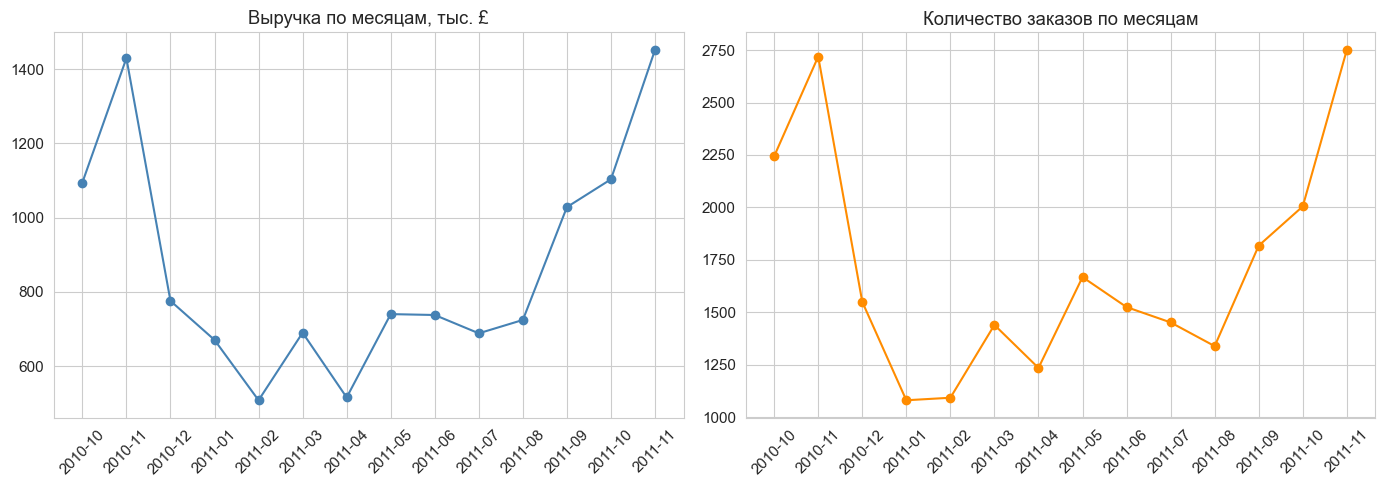

YearMonth      Revenue  Orders  Quantity  SKU    AOV
  2010-10 1,094,435.98    2244    619511 2786 487.72
  2010-11 1,429,700.78    2719    724263 2950 525.82
  2010-12   775,640.91    1550    357530 2723 500.41
  2011-01   670,380.24    1081    386738 2527 620.15
  2011-02   507,799.87    1093    282627 2346 464.59
  2011-03   689,833.51    1440    376182 2451 479.05
  2011-04   515,377.99    1235    307650 2410 417.31
  2011-05   739,953.00    1668    394653 2408 443.62
  2011-06   737,558.98    1525    388124 2578 483.65
  2011-07   688,219.34    1452    399290 2633 473.98
  2011-08   724,216.50    1339    420695 2552 540.86
  2011-09 1,028,320.38    1818    568700 2692 565.63
  2011-10 1,103,314.25    2005    619597 2798 550.28
  2011-11 1,452,115.98    2751    746952 2890 527.85


In [23]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly = df.groupby('YearMonth').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('Invoice', 'nunique'),
    Quantity=('Quantity', 'sum'),
    SKU=('StockCode', 'nunique'),
).reset_index()
monthly['AOV'] = monthly['Revenue'] / monthly['Orders']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(monthly['YearMonth'].astype(str), monthly['Revenue'] / 1000,
             marker='o', color='steelblue')
axes[0].set_title('Выручка по месяцам, тыс. £')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly['YearMonth'].astype(str), monthly['Orders'],
             marker='o', color='darkorange')
axes[1].set_title('Количество заказов по месяцам')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(monthly.to_string(index=False))

<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

**Сезонность ярко выражена:**  

Минимум **февраль 2011** - £507.8K, 1 093 заказа.  
Пик **ноябрь 2010 и ноябрь 2011**, оба месяца показали ~£1.43M выручки, что подтверждает устойчивый предрождественский пик.  
Октябрь-ноябрь стабильно дают высокую выручку, а летние месяцы и февраль заметно ниже.  

Средний чек колеблется от £417 (апрель 2011) до £620 (январь 2011), что говорит о разной структуре заказов в сезоны.  

Сезонность - не «нестабильность спроса», а ожидаемое поведение. При классификации коэффициента вариации это надо учитывать: товары с предсказуемым ноябрьским пиком, попавшие в Z, не идут сразу в исключение.  

</div>

## Концентрация выручки по SKU

In [24]:
sku_rev = (df.groupby('StockCode')
             .agg(Revenue=('Revenue', 'sum'),
                  Quantity=('Quantity', 'sum'),
                  Description=('Description', 'first'))
             .sort_values('Revenue', ascending=False)
             .reset_index())

sku_rev['RevenueShare'] = sku_rev['Revenue'] / sku_rev['Revenue'].sum()
sku_rev['CumShare'] = sku_rev['RevenueShare'].cumsum()

print('ТОП-10 SKU по выручке:')
print(sku_rev.head(10)[['StockCode', 'Description', 'Revenue', 'RevenueShare']].to_string(index=False))

low_skus = sku_rev[sku_rev['Revenue'] < 100]
print(f'\nSKU с выручкой < £100: {len(low_skus)} '
      f'({len(low_skus)/len(sku_rev)*100:.1f}% ассортимента), '
      f'дают {low_skus["Revenue"].sum()/sku_rev["Revenue"].sum()*100:.3f}% выручки')

ТОП-10 SKU по выручке:
StockCode                         Description    Revenue  RevenueShare
    22423            REGENCY CAKESTAND 3 TIER 220,103.01          0.02
   85123A  WHITE HANGING HEART T-LIGHT HOLDER 135,248.81          0.01
   85099B             JUMBO BAG RED RETROSPOT 111,528.27          0.01
    47566                       PARTY BUNTING 105,305.66          0.01
    22086     PAPER CHAIN KIT 50'S CHRISTMAS   94,762.16          0.01
    23166      MEDIUM CERAMIC TOP STORAGE JAR  81,448.21          0.01
    84879       ASSORTED COLOUR BIRD ORNAMENT  80,755.05          0.01
    79321                       CHILLI LIGHTS  64,404.69          0.01
    22197                SMALL POPCORN HOLDER  60,117.41          0.00
    84347 ROTATING SILVER ANGELS T-LIGHT HLDR  58,325.97          0.00

SKU с выручкой < £100: 804 (20.2% ассортимента), дают 0.269% выручки


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

**Топ-10 SKU** состоит из реальных товаров, служебные коды (`DOT`, `M`, `POST`) исключены. Лидер `22423 REGENCY CAKESTAND 3 TIER` (£220 103). Далее идут `85123A WHITE HANGING HEART T-LIGHT HOLDER` (£135 249) и `85099B JUMBO BAG RED RETROSPOT` (£111 528).

**804 SKU (20.2%) с выручкой < £100** дают суммарно **0.269%** выручки. Это «длинный хвост» из микро-товаров, именно он будет основным пулом кандидатов на сокращение.

</div>

## ABC-анализ

ABC-АНАЛИЗ:
ABC  SKU      Revenue  SKU_share  Revenue_share
  A  862 9,724,480.86       0.22           0.80
  B  994 1,823,607.41       0.25           0.15
  C 2132   608,779.44       0.53           0.05


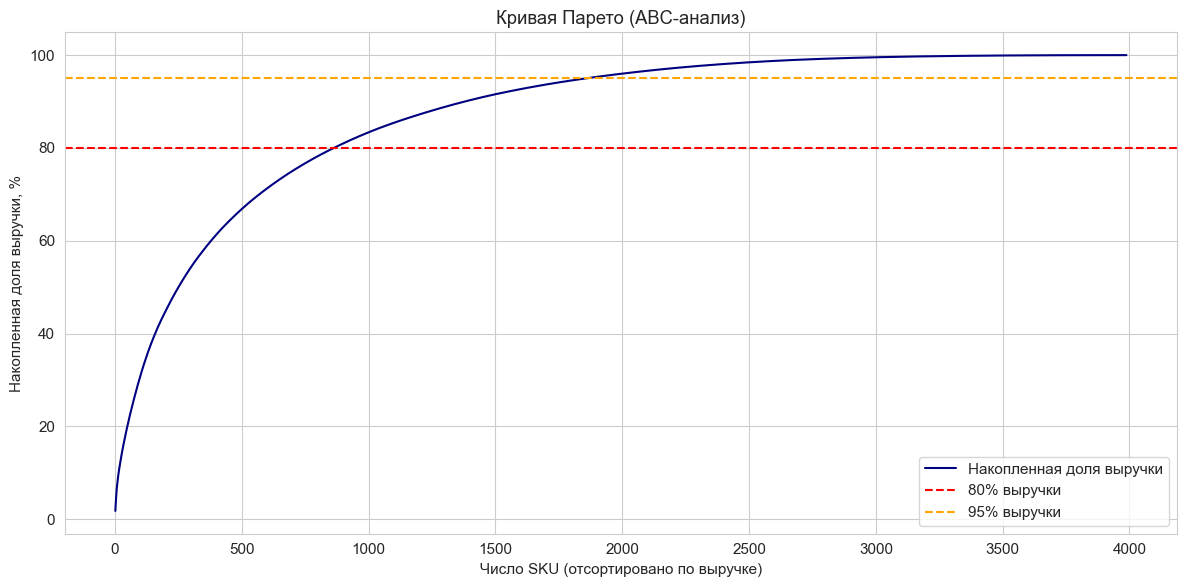

In [25]:
abc = sku_rev.copy()

def abc_category(cum_share):
    if cum_share <= 0.80:
        return 'A'
    elif cum_share <= 0.95:
        return 'B'
    else:
        return 'C'

abc['ABC'] = abc['CumShare'].apply(abc_category)

abc_summary = abc.groupby('ABC').agg(
    SKU=('StockCode', 'count'),
    Revenue=('Revenue', 'sum'),
).reset_index()
abc_summary['SKU_share'] = abc_summary['SKU'] / abc_summary['SKU'].sum()
abc_summary['Revenue_share'] = abc_summary['Revenue'] / abc_summary['Revenue'].sum()

print('ABC-АНАЛИЗ:')
print(abc_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(1, len(abc) + 1)
ax.plot(x, abc['CumShare'] * 100, color='navy', label='Накопленная доля выручки')
ax.axhline(80, color='red', linestyle='--', label='80% выручки')
ax.axhline(95, color='orange', linestyle='--', label='95% выручки')
ax.set_xlabel('Число SKU (отсортировано по выручке)')
ax.set_ylabel('Накопленная доля выручки, %')
ax.set_title('Кривая Парето (ABC-анализ)')
ax.legend()
plt.tight_layout()
plt.show()

<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

| Категория | SKU | Доля SKU | Выручка, £ | Доля выручки |
|-----------|-----|----------|-----------|--------------|
| A | 862 | 22% | 9 724 481 | **80%** |
| B | 994 | 25% | 1 823 607 | **15%** |
| C | 2 132 | 53% | 608 779 | **5%** |

**Классическая Парето-картина:** ~22% ассортимента создаёт 80% выручки. Категория C более половины SKU, но лишь 5% выручки.

**Ключевой вывод:**
Часть C-товаров может быть:
- дополнением к основным покупкам (basket drivers),
- сезонными позициями (ёлочные игрушки, подарочные упаковки),
- новинками, ещё не раскрутившимися,
- нишевыми, но маржинальными.

</div>

## Динамический ABC по кварталам

Статический ABC выше показывает структуру за весь 14-месячный период.  
Но товар может быть «звездой» сейчас и «умирающим» через 2 месяца и наоборот.  
Динамический ABC разбивает период на 4 квартала и считает ABC **в каждом квартале отдельно**,  
после чего отслеживает миграцию SKU между категориями.  

**Зачем это нужно:**
- показать, что ABC не статичный ярлык, а инструмент мониторинга;  
- выявить товары-«восходящие звёзды» (C → A) и «падающие звёзды» (A → C);  
- снизить риск удалить товар, который только начинает набирать обороты;  
- дать бизнесу сигнал «кто требует пересмотра ассортимента в следующем квартале».  

In [26]:
df['Quarter'] = df['InvoiceDate'].dt.to_period('Q')

def is_full_quarter(q):
    months_in_q = df[df['Quarter'] == q]['InvoiceDate'].dt.month.nunique()
    return months_in_q == 3

all_quarters = sorted(df['Quarter'].unique())
quarters = [q for q in all_quarters if is_full_quarter(q)]

print('Все кварталы в периоде:', all_quarters)
print('Полные кварталы (используются в ABC):', quarters)
print(f'Исключены неполные: {[str(q) for q in all_quarters if q not in quarters]}')

def abc_categorize(values):
    """Присваивает A/B/C по накопленной доле выручки (80/95%)."""
    s = pd.Series(values).sort_values(ascending=False)
    share = s / s.sum()
    cum = share.cumsum()
    cats = pd.Series(
        np.where(cum <= 0.80, 'A', np.where(cum <= 0.95, 'B', 'C')),
        index=s.index
    )
    return cats

quarterly_abc = {}
for q in quarters:
    sub = (df[df['Quarter'] == q]
           .groupby('StockCode')['Revenue']
           .sum())
    quarterly_abc[q] = abc_categorize(sub)

quarterly_matrix = pd.DataFrame(quarterly_abc)
quarterly_matrix = quarterly_matrix.fillna('—')

quarterly_matrix = quarterly_matrix.loc[
    quarterly_matrix.index.isin(df['StockCode'].unique())
]

print(f'\nРазмер quarterly_matrix: {quarterly_matrix.shape}')
print('Примеры (первые 10 SKU):')
print(quarterly_matrix.head(10).to_string())
print('\nРаспределение SKU по категориям в каждом квартале:')
for q in quarters:
    counts = quarterly_matrix[q].value_counts().reindex(['A', 'B', 'C', '—'], fill_value=0)
    shares = (counts / counts.sum() * 100).round(1)
    print(f'{q}:  A={counts["A"]:>4} ({shares["A"]:>5}%) | '
          f'B={counts["B"]:>4} ({shares["B"]:>5}%) | '
          f'C={counts["C"]:>4} ({shares["C"]:>5}%) | '
          f'нет продаж={counts["—"]:>4}')

Все кварталы в периоде: [Period('2010Q4', 'Q-DEC'), Period('2011Q1', 'Q-DEC'), Period('2011Q2', 'Q-DEC'), Period('2011Q3', 'Q-DEC'), Period('2011Q4', 'Q-DEC')]
Полные кварталы (используются в ABC): [Period('2010Q4', 'Q-DEC'), Period('2011Q1', 'Q-DEC'), Period('2011Q2', 'Q-DEC'), Period('2011Q3', 'Q-DEC')]
Исключены неполные: ['2011Q4']

Размер quarterly_matrix: (3838, 4)
Примеры (первые 10 SKU):
          2010Q4 2011Q1 2011Q2 2011Q3
StockCode                            
10002          A      B      C      —
10080          C      C      C      C
10120          C      C      C      C
10123C         C      C      —      —
10123G         C      —      —      —
10124A         C      C      —      —
10124G         C      C      —      C
10125          B      B      C      B
10133          C      B      B      B
10134          C      —      —      —

Распределение SKU по категориям в каждом квартале:
2010Q4:  A= 641 ( 16.7%) | B= 772 ( 20.1%) | C=1807 ( 47.1%) | нет продаж= 618
2011Q1:  A= 61

In [27]:
def stable_in_c(row):
    active = row[row != '—']
    return len(active) >= 2 and (active == 'C').all()

quarterly_matrix['StableC'] = quarterly_matrix.apply(stable_in_c, axis=1)
stable_c_skus = set(quarterly_matrix[quarterly_matrix['StableC']].index)

print(f"SKU с устойчивой категорией C (во всех активных кварталах): {len(stable_c_skus)}")

SKU с устойчивой категорией C (во всех активных кварталах): 1260


In [28]:
first_q = quarters[0]
last_q = quarters[-1]

mig = quarterly_matrix[[first_q, last_q]].copy()
mig.columns = ['Q_first', 'Q_last']

mig_stable = mig[(mig['Q_first'] != '—') & (mig['Q_last'] != '—')].copy()
transition = pd.crosstab(mig_stable['Q_first'], mig_stable['Q_last'],
                         rownames=['Было'], colnames=['Стало'])
print(f'Матрица переходов ABC  ({first_q} → {last_q}):')
print(transition.to_string())

upgrades = mig_stable[(mig_stable['Q_first'] == 'C') & (mig_stable['Q_last'].isin(['A', 'B']))]
downgrades = mig_stable[(mig_stable['Q_first'].isin(['A', 'B'])) & (mig_stable['Q_last'] == 'C')]

print(f'\nВосходящих звёзд (C → A/B): {len(upgrades)}')
print(f'Падающих звёзд (A/B → C):  {len(downgrades)}')

info = (df.groupby('StockCode')
          .agg(Description=('Description', 'first'),
               Revenue=('Revenue', 'sum')))

print('\nТОП-10 восходящих звёзд (по выручке за период):')
up_detail = (upgrades.join(info)
             .sort_values('Revenue', ascending=False)
             .head(10))
print(up_detail.to_string())

print('\nТОП-10 падающих звёзд (по выручке за период):')
down_detail = (downgrades.join(info)
               .sort_values('Revenue', ascending=False)
               .head(10))
print(down_detail.to_string())

Матрица переходов ABC  (2010Q4 → 2011Q3):
Стало    A    B     C
Было                 
A      399  149    51
B       51  341   294
C       10  129  1081

Восходящих звёзд (C → A/B): 139
Падающих звёзд (A/B → C):  345

ТОП-10 восходящих звёзд (по выручке за период):
          Q_first Q_last                       Description  Revenue
StockCode                                                          
22970           C      A             LONDON BUS COFFEE MUG 9,914.07
21770           C      A            OPEN CLOSED METAL SIGN 7,483.65
22971           C      A           QUEENS GUARD COFFEE MUG 5,737.93
21932           C      A   SCANDINAVIAN PAISLEY PICNIC BAG 5,094.12
21933           C      A   PINK VINTAGE PAISLEY PICNIC BAG 4,974.52
22302           C      A          COFFEE MUG PEARS  DESIGN 4,969.10
22721           C      B     SET OF 3 CAKE TINS SKETCHBOOK 4,252.32
22117           C      A  METAL SIGN HER DINNER IS SERVED  4,094.10
22723           C      B     SET OF 6 HERB TINS SKETCHB

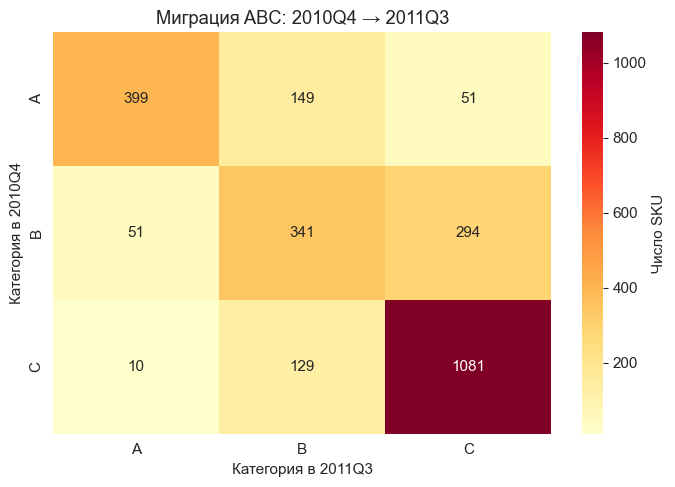


Доля SKU, сменивших ABC-категорию за период 2010Q4→2011Q3: 27.3%
Устойчивость A: 399 из 599 (66.6%) остались в A.


In [29]:
order = ['A', 'B', 'C']
transition_ordered = transition.reindex(index=order, columns=order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(transition_ordered, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Число SKU'}, ax=ax)
ax.set_title(f'Миграция ABC: {first_q} → {last_q}')
ax.set_xlabel(f'Категория в {last_q}')
ax.set_ylabel(f'Категория в {first_q}')
plt.tight_layout()
plt.show()

mig_stable['Changed'] = mig_stable['Q_first'] != mig_stable['Q_last']
churn_pct = mig_stable['Changed'].mean() * 100
print(f'\nДоля SKU, сменивших ABC-категорию за период '
      f'{first_q}→{last_q}: {churn_pct:.1f}%')

a_stable = mig_stable[(mig_stable['Q_first'] == 'A') &
                      (mig_stable['Q_last'] == 'A')]
a_total  = (mig_stable['Q_first'] == 'A').sum()
print(f'Устойчивость A: {len(a_stable)} из {a_total} '
      f'({len(a_stable)/a_total*100:.1f}%) остались в A.')

<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

1. **Распределение по категориям меняется от квартала к кварталу (4 полных квартала):**

| Квартал | A | B | C | Нет продаж |
|---------|---|---|---|-----------|
| 2010Q4 | 641 (16.7%) | 772 (20.1%) | 1 807 (47.1%) | 618 |
| 2011Q1 | 616 (16.1%) | 730 (19.0%) | 1 555 (40.5%) | 937 |
| 2011Q2 | 594 (15.5%) | 729 (19.0%) | 1 702 (44.3%) | 813 |
| 2011Q3 | 659 (17.2%) | 787 (20.5%) | 1 603 (41.8%) | 789 |

Распределение колеблется, но без катастрофических скачков. Доля A-категории стабильна в районе 15–17%.

2. **Матрица переходов 2010Q4 → 2011Q3** (для SKU, которые были активны в обоих крайних кварталах):

| Было \ Стало | A | B | C |
|--------------|---|---|---|
| **A** | 399 | 149 | 51 |
| **B** | 51 | 341 | 294 |
| **C** | 10 | 129 | 1 081 |

- **27.3% SKU** сменили ABC-категорию за период.
- **Устойчивость A:** 399 из 599 (66.6%) остались в A. То есть треть «звёзд» первого квартала к концу периода ушла вниз.
- **139 «восходящих звёзд»** (C → A/B): товары, которые начинали плохо, но разогнались к концу периода. Примеры:
  - `22970 LONDON BUS COFFEE MUG` — £9 914
  - `21770 OPEN CLOSED METAL SIGN` — £7 484
  - `22971 QUEENS GUARD COFFEE MUG` — £5 738
- **345 «падающих звёзд»** (A/B → C): товары с угасающим спросом. Примеры:
  - `22084 PAPER CHAIN KIT EMPIRE` — £16 748
  - `22837 HOT WATER BOTTLE BABUSHKA` — £16 455
  - `20975 12 PENCILS SMALL TUBE RED SPOTTY` — £6 871

3. **Практический вывод:**
   - ABC это **снимок за период**, а не постоянный ярлык. Товар может за год пройти путь C → A и наоборот.
   - Товары, которые в **последнем квартале** попали в A или B, не должны попадать в список на вывод, даже если их средняя выручка за год низкая.
   - Товары, которые **устойчиво в C все активные кварталы**, наиболее безопасные кандидаты на сокращение. Однако важно помнить, что это правило не защищает от сезонных товаров, у которых пик продаж приходится на месяцы, не попавшие в полные кварталы (например, октябрь-ноябрь).
   - Найдено 139 «восходящих звёзд», на которые стоит обратить внимание.

</div>

## XYZ-анализ с полным 14-месячным календарём

Распределение CV:
count   3,988.00
mean        1.59
std         0.87
min         0.34
25%         0.91
50%         1.37
75%         2.05
max         3.74
Name: CV, dtype: float64

Распределение XYZ:
XYZ
Z    2806
Y    1069
X     113
Name: count, dtype: int64


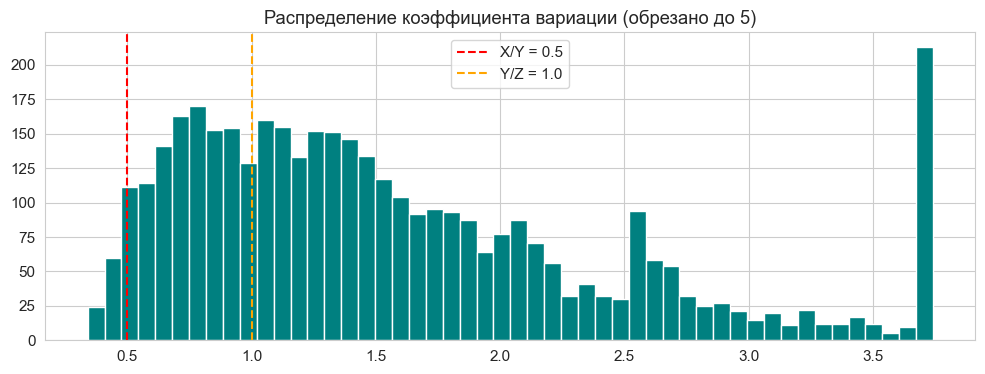

In [30]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
all_months = pd.period_range(PERIOD_START, PERIOD_END, freq='M')

sku_month = (df.groupby(['StockCode', 'YearMonth'])['Quantity']
               .sum()
               .unstack(fill_value=0))

sku_month = sku_month.reindex(columns=all_months, fill_value=0)

xyz = pd.DataFrame(index=sku_month.index)
xyz['MeanQty'] = sku_month.mean(axis=1)
xyz['StdQty'] = sku_month.std(axis=1, ddof=0)
xyz['CV'] = np.where(xyz['MeanQty'] > 0, xyz['StdQty'] / xyz['MeanQty'], np.nan)
xyz['ActiveMonths'] = (sku_month > 0).sum(axis=1)
xyz['TotalQty'] = sku_month.sum(axis=1)

def xyz_category(cv):
    if pd.isna(cv):
        return 'Z'
    if cv <= 0.5:
        return 'X'
    elif cv <= 1.0:
        return 'Y'
    else:
        return 'Z'

xyz['XYZ'] = xyz['CV'].apply(xyz_category)

print('Распределение CV:')
print(xyz['CV'].describe())
print('\nРаспределение XYZ:')
print(xyz['XYZ'].value_counts())

fig, ax = plt.subplots(figsize=(12, 4))
xyz['CV'].clip(upper=5).hist(bins=50, ax=ax, color='teal')
ax.axvline(0.5, color='red', linestyle='--', label='X/Y = 0.5')
ax.axvline(1.0, color='orange', linestyle='--', label='Y/Z = 1.0')
ax.set_title('Распределение коэффициента вариации (обрезано до 5)')
ax.legend()
plt.show()

<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

Метод: для каждого SKU построен **полный ряд по всем месяцам периода** (все пропущенные месяцы = 0), затем CV = std / mean.

**Распределение CV:** медиана 1.37, среднее 1.59, 75-й перцентиль 2.05 — большинство SKU высоко вариативны.

| Категория | SKU | Доля | Интерпретация |
|-----------|-----|------|---------------|
| X (CV ≤ 0.5) | 113 | 2.8% | стабильный спрос |
| Y (0.5 < CV ≤ 1.0) | 1 069 | 26.8% | умеренно вариативный |
| Z (CV > 1.0) | 2 806 | 70.4% | сильно вариативный / редкий |

**Почему Z так много:**
1. Нулевые месяцы честно учтены, даже один-два «пустых» месяца резко поднимают CV.
2. Сезонность: товары, которые продаются только в октябре-ноябре, имеют почти нулевую выручку в остальные 11 месяцев → CV > 1.
3. Редкие крупные заказы (B2B).

</div>

## Объединённая матрица ABC/XYZ

Отсутствующие столбцы: нет
Столбцы matrix: ['StockCode', 'Revenue', 'RevenueShare', 'ABC', 'XYZ', 'CV', 'MeanQty', 'StdQty', 'ActiveMonths', 'Description', 'Quantity', 'Orders', 'Customers', 'AvgPrice', 'ABC_XYZ']

Распределение по группам ABC/XYZ:
ABC_XYZ  SKU      Revenue  Quantity  Orders  Customers  SKU_share  Revenue_share
     AX   80 1,426,195.64    797773   14977       3867       0.02           0.12
     AY  418 5,011,914.73   2320649   21328       4701       0.10           0.41
     AZ  364 3,286,370.49   1376564   18679       4425       0.09           0.27
     BX   28    61,948.88     65765    4178       1655       0.01           0.01
     BY  364   675,741.86    657769   14121       3939       0.09           0.06
     BZ  602 1,085,916.67    769902   15510       4192       0.15           0.09
     CX    5     4,249.28      8306     737        394       0.00           0.00
     CY  287   134,905.11    145503    6674       2485       0.07           0.01
     CZ 1840   469,625

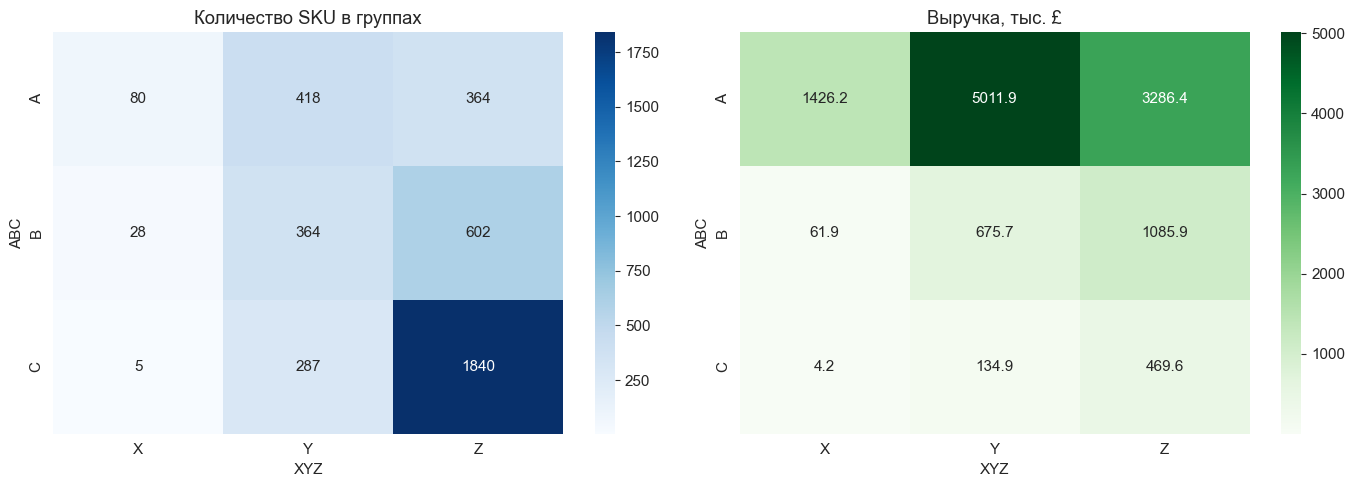

In [31]:
extra = df.groupby('StockCode').agg(
    Description=('Description', 'first'),
    Revenue=('Revenue', 'sum'),
    Quantity=('Quantity', 'sum'),
    Orders=('Invoice', 'nunique'),
    Customers=('Customer ID', 'nunique'),
).reset_index()
extra['AvgPrice'] = extra['Revenue'] / extra['Quantity']

matrix = (abc[['StockCode', 'Revenue', 'RevenueShare', 'ABC']]
          .merge(xyz[['XYZ', 'CV', 'MeanQty', 'StdQty', 'ActiveMonths']],
                 left_on='StockCode', right_index=True, how='left')
          .merge(extra[['StockCode', 'Description', 'Quantity',
                        'Orders', 'Customers', 'AvgPrice']],
                 on='StockCode', how='left'))

matrix['ABC_XYZ'] = matrix['ABC'] + matrix['XYZ']

required_cols = ['StockCode', 'Description', 'ABC', 'XYZ', 'ABC_XYZ',
                 'Revenue', 'RevenueShare', 'Quantity', 'Orders',
                 'Customers', 'ActiveMonths', 'CV', 'AvgPrice']
missing_cols = [c for c in required_cols if c not in matrix.columns]
print('Отсутствующие столбцы:', missing_cols if missing_cols else 'нет')
print('Столбцы matrix:', list(matrix.columns))

print('\nРаспределение по группам ABC/XYZ:')

sku_to_group = matrix.set_index('StockCode')['ABC_XYZ'].to_dict()
df['ABC_XYZ_temp'] = df['StockCode'].map(sku_to_group)

summary = df.groupby('ABC_XYZ_temp').agg(
    SKU=('StockCode', 'nunique'),
    Revenue=('Revenue', 'sum'),
    Quantity=('Quantity', 'sum'),
    Orders=('Invoice', 'nunique'),
    Customers=('Customer ID', 'nunique')
).reset_index().rename(columns={'ABC_XYZ_temp': 'ABC_XYZ'})

summary['SKU_share'] = summary['SKU'] / summary['SKU'].sum()
summary['Revenue_share'] = summary['Revenue'] / summary['Revenue'].sum()
print(summary.sort_values('ABC_XYZ').to_string(index=False))

df.drop(columns=['ABC_XYZ_temp'], inplace=True)

pivot_sku = matrix.pivot_table(index='ABC', columns='XYZ',
                               values='StockCode', aggfunc='count').fillna(0)
pivot_rev = matrix.pivot_table(index='ABC', columns='XYZ',
                               values='Revenue', aggfunc='sum').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pivot_sku, annot=True, fmt='.0f', cmap='Blues', ax=axes[0])
axes[0].set_title('Количество SKU в группах')
sns.heatmap(pivot_rev / 1000, annot=True, fmt='.1f', cmap='Greens', ax=axes[1])
axes[1].set_title('Выручка, тыс. £')
plt.tight_layout()
plt.show()

<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

| Группа | SKU | Доля SKU | Выручка, £ | Доля выручки |
|--------|-----|----------|-----------|--------------|
| **AX** | 80 | 2% | 1 426 196 | **12%** |
| **AY** | 418 | 10% | 5 011 915 | **41%** |
| **AZ** | 364 | 9% | 3 286 370 | **27%** |
| BX | 28 | 1% | 61 949 | 1% |
| BY | 364 | 9% | 675 742 | 6% |
| BZ | 602 | 15% | 1 085 917 | 9% |
| CX | 5 | 0.1% | 4 249 | 0.1% |
| CY | 287 | 7% | 134 905 | 1% |
| **CZ** | 1 840 | **46%** | 469 625 | **4%** |

**Наблюдения:**
- **A-блок (AX+AY+AZ) = 862 SKU (22%) → 80% выручки.** Внутри A особенно весомы AY и AZ это говорит о том, что даже высокодоходные товары имеют заметную вариативность спроса.
- **CZ самая многочисленная группа** (46% ассортимента), но даёт всего 4% выручки. Это естественный пул для проверки, но **не для автоматического удаления**.
- Группа **CX** крошечная: всего 5 SKU, но они стабильны при низкой выручке. Это кандидаты на проверку роли в корзине.

</div>

## Проверка сезонности

In [32]:
first_month = df.groupby('StockCode')['YearMonth'].min()
matrix['FirstMonth'] = matrix['StockCode'].map(first_month)

all_months = pd.period_range(PERIOD_START, PERIOD_END, freq='M')
last_3_months = all_months[-3:]
matrix['IsNew'] = matrix['FirstMonth'].isin(last_3_months)

seasonal_months = [pd.Period('2010-10', 'M'), pd.Period('2011-11', 'M')]
seasonal_revenue = df[df['YearMonth'].isin(seasonal_months)].groupby('StockCode')['Revenue'].sum()
total_revenue = df.groupby('StockCode')['Revenue'].sum()
seasonal_share = (seasonal_revenue / total_revenue).fillna(0)
seasonal_skus = set(seasonal_share[seasonal_share > 0.2].index)

print(f"Найдено {len(seasonal_skus)} SKU с высокой сезонной долей (>20%) в октябре-ноябре.")
print(f"Из них попадают в StableC: {len(seasonal_skus & stable_c_skus)} SKU — "
      f"их стоит проверить вручную перед выводом.")

Найдено 1853 SKU с высокой сезонной долей (>20%) в октябре-ноябре.
Из них попадают в StableC: 514 SKU — их стоит проверить вручную перед выводом.


<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

Дополнительно проверено, как соотносятся сезонные товары с фильтром `StableC`. Результат:

- **1853 SKU (46.5% ассортимента)** имеют долю выручки в октябре-ноябре выше 20% от общей за период. Это ожидаемо, в ноябре предрождественский пик, и почти половина магазина «работает» именно на этот сезон.
- Из них **514 SKU попадают в категорию `StableC`** (устойчиво в C во всех активных кварталах). То есть формально они «стабильно плохие» по ABC-кварталам, но при этом дают заметную долю продаж в сезонные месяцы, которые в квартальный анализ не попали.

**Практический вывод:** эти 514 SKU — потенциальная зона риска для автоматического удаления. Если бы мы отбирали кандидатов только по фильтрам ABC/XYZ + `StableC`, они бы прошли, но их удаление могло бы лишить магазин сезонных продаж в октябре-ноябре (которые не входят в полные кварталы 2010Q4 и 2011Q4). Такие позиции требуют ручной проверки перед любым решением о выводе.

</div>

## Кандидаты на сокращение

Кандидаты на вывод отбираются по пяти фильтрам одновременно:
- принадлежность к группе CZ/BZ (низкая выручка + нестабильный спрос),
- клиентская база менее 20 покупателей (большое количество покупателей говорит о востребованности товара),
- активность менее 10 месяцев из 14,
- средняя цена не выше £10 (сохранение нишевых дорогих позиций),
- товар не является новинкой (появился более 3 месяцев назад)

### Альтернативный вариант: с фильтром `StableC`

Дополнительно проверяем, как изменится список кандидатов, если добавить устойчивость в категории C по всем кварталам (`StableC = True`), рассчитанный на основе динамического ABC.

Логика: товар должен быть в C **все активные кварталы**, без всплесков в A/B. Это делает список безопаснее, но и короче часть SKU с потенциальными всплесками спроса в него не попадёт.


In [33]:
revenue_with_customer = df[df['Customer ID'].notna()].groupby('StockCode')['Revenue'].sum()
total_revenue_per_sku = df.groupby('StockCode')['Revenue'].sum()
customer_data_coverage = (revenue_with_customer / total_revenue_per_sku).fillna(0)

matrix['CustomerRevenueCoverage'] = matrix['StockCode'].map(customer_data_coverage)


def show_candidates(use_stable_c=False, label=''):
    base_mask = (
        (matrix['ABC_XYZ'].isin(['CZ', 'BZ'])) &
        (matrix['ActiveMonths'] < 10) &
        (matrix['AvgPrice'] <= 10) &
        (~matrix['IsNew'])
    )

    if use_stable_c:
        base_mask &= matrix['StockCode'].isin(stable_c_skus)

    main_mask = base_mask & (matrix['CustomerRevenueCoverage'] >= 0.5) & (matrix['Customers'].fillna(0) < 20)
    review_mask = base_mask & (matrix['CustomerRevenueCoverage'] < 0.5)

    cand_main = matrix[main_mask].copy()
    cand_review = matrix[review_mask].copy()

    cand_main['Recommendation'] = 'Проверить на вывод'
    cand_review['Recommendation'] = 'Проверить (низкое покрытие клиентских данных)'

    cand = pd.concat([cand_main, cand_review], ignore_index=True)

    total_sku = len(matrix)
    total_rev = matrix['Revenue'].sum()
    cand_sku = len(cand)
    cand_rev = cand['Revenue'].sum()

    print('=' * 60)
    print(f'РЕЗУЛЬТАТ ОТБОРА КАНДИДАТОВ {label}')
    print('=' * 60)
    print(f'Всего SKU в анализе:               {total_sku}')
    print(f'Всего кандидатов:                  {cand_sku} ({cand_sku/total_sku*100:.1f}%)')
    print(f'  - Основные кандидаты:            {len(cand_main)} ({len(cand_main)/total_sku*100:.1f}%)')
    print(f'  - На отдельную проверку (низкое покрытие клиентских данных): '
          f'{len(cand_review)} ({len(cand_review)/total_sku*100:.1f}%)')
    print(f'Выручка кандидатов (всего):        £{cand_rev:,.2f}')
    print(f'  - Выручка основных:              £{cand_main["Revenue"].sum():,.2f}')
    print(f'  - Выручка на проверку:           £{cand_review["Revenue"].sum():,.2f}')
    print(f'Доля выручки кандидатов:           {cand_rev/total_rev*100:.2f}%')
    print(f'Средняя выручка кандидата:         £{cand_rev/cand_sku:,.2f}')
    print('\\nКандидаты по группам ABC/XYZ:')
    print(cand['ABC_XYZ'].value_counts())
    print()
    return cand, total_sku, total_rev, cand_sku, cand_rev


candidates_basic, _, _, cand_sku_basic, cand_rev_basic = show_candidates(
    use_stable_c=False, label='(базовый)'
)

candidates, total_sku, total_rev, cand_sku, cand_rev = show_candidates(
    use_stable_c=True, label='(альтернативный, + StableC)'
)

candidates_main = candidates[candidates['Recommendation'] == 'Проверить на вывод'].copy()
candidates_review = candidates[candidates['Recommendation'] == 'Проверить (низкое покрытие клиентских данных)'].copy()

РЕЗУЛЬТАТ ОТБОРА КАНДИДАТОВ (базовый)
Всего SKU в анализе:               3988
Всего кандидатов:                  970 (24.3%)
  - Основные кандидаты:            762 (19.1%)
  - На отдельную проверку (низкое покрытие клиентских данных): 208 (5.2%)
Выручка кандидатов (всего):        £108,349.31
  - Выручка основных:              £88,244.62
  - Выручка на проверку:           £20,104.69
Доля выручки кандидатов:           0.89%
Средняя выручка кандидата:         £111.70
\nКандидаты по группам ABC/XYZ:
ABC_XYZ
CZ    962
BZ      8
Name: count, dtype: int64

РЕЗУЛЬТАТ ОТБОРА КАНДИДАТОВ (альтернативный, + StableC)
Всего SKU в анализе:               3988
Всего кандидатов:                  611 (15.3%)
  - Основные кандидаты:            473 (11.9%)
  - На отдельную проверку (низкое покрытие клиентских данных): 138 (3.5%)
Выручка кандидатов (всего):        £62,773.50
  - Выручка основных:              £51,136.94
  - Выручка на проверку:           £11,636.56
Доля выручки кандидатов:           0.52%
С

<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Сравнение двух вариантов отбора

| Параметр | Базовый (5 фильтров) | Расширенный (+ `StableC`) | Разница |
|----------|---------------------|---------------------------|---------|
| Кандидатов, SKU | 970 | 611 | −359 |
| Доля SKU | 24.3% | 15.3% | −9.0 п.п. |
| Выручка кандидатов, £ | 108 349 | 62 774 | −45 575 |
| Доля выручки | 0.89% | 0.52% | −0.37 п.п. |
| Средняя выручка кандидата, £ | 111.70 | 102.74 | −8.96 |
| Категории кандидатов | 962 CZ + 8 BZ | 610 CZ + 1 BZ | почти только CZ |

**Что отсекает `StableC`:**
- **359 SKU**, которые в каком-то квартале имели всплеск в A или B. Это товары с нестабильным, но ненулевым потенциалом спроса.
- Почти все SKU из группы BZ также отсеиваются после добавления `StableC` в кандидатах остался только **1 BZ** (который с 4 квартала 2010 по 3 квартал 2011 был в C, а в последнем квартале 2011 выбрался в B).

**Какой вариант выбрать:**
- **Базовый (24.3% SKU → 0.89% выручки)** агрессивный, ближе к бизнес-ориентиру «минус 20% ассортимента» (даже перевыполняет его). Подходит, если цель быстро освободить склад и упростить учёт, а также если есть ресурс на ручную проверку.
- **Альтернативный (15.3% SKU → 0.52% выручки)** консервативный, безопаснее, но не дотягивает до ориентира 20%. Подходит, если приоритет не потерять «спящую» позицию с потенциалом.

**Важное дополнение про полноту клиентских данных:**
Среди кандидатов часть SKU имеет **низкое покрытие клиентских данных** (менее 50% выручки приходится на операции с известным `Customer ID`). Для них фильтр «< 20 покупателей» ненадёжен: низкое число известных клиентов может означать отсутствие идентификаторов в заказах, а не отсутствие спроса. Эти SKU вынесены в отдельную группу **«Проверить (низкое покрытие клиентских данных)»** и требуют ручной проверки перед решением о выводе.

Для альтернативного варианта:
- Основные кандидаты: **473 SKU**, выручка **£51 137**.
- На отдельную проверку: **138 SKU**, выручка **£11 637**.

**Рекомендация:** взять за основу **альтернативный вариант**, но основные кандидаты можно сокращать сразу, а группу «на проверку» — только после ручного анализа. Базовый вариант использовать как «верхнюю границу» сокращения, если бизнес готов к более решительным действиям.

**Далее используется Альтернативный вариант.**

</div>

## Финальная таблица кандидатов

In [34]:
final_cols = ['StockCode', 'Description', 'ABC', 'XYZ', 'ABC_XYZ',
              'Revenue', 'RevenueShare', 'Quantity', 'Orders',
              'Customers', 'ActiveMonths', 'CV', 'AvgPrice', 'Recommendation']

candidates_final = candidates[final_cols].copy()
candidates_final['RevenueShare'] = (candidates_final['RevenueShare'] * 100).round(8)
candidates_final['CV'] = candidates_final['CV'].round(2)
candidates_final['AvgPrice'] = candidates_final['AvgPrice'].round(2)
candidates_final['Revenue'] = candidates_final['Revenue'].round(2)

print('ТОП-20 кандидатов (наименьшая выручка):')
print(candidates_final.head(20).to_string(index=False))

candidates_final.to_csv('candidates_for_removal.csv', index=False)
print('\nФайл candidates_for_removal.csv сохранён.')

ТОП-20 кандидатов (наименьшая выручка):
StockCode                         Description ABC XYZ ABC_XYZ  Revenue  RevenueShare  Quantity  Orders  Customers  ActiveMonths   CV  AvgPrice     Recommendation
    84609           TALL ROCOCO CANDLE HOLDER   B   Z      BZ   957.57          0.01       114      25         18             9 1.30      8.40 Проверить на вывод
    23016             GLASS TWIST BON BON JAR   C   Z      CZ   536.00          0.00        69      22         17             6 1.55      7.77 Проверить на вывод
    84917     WHITE HAND TOWEL WITH BUTTERFLY   C   Z      CZ   495.77          0.00       191      32         13             7 1.94      2.60 Проверить на вывод
    23043 PAPER LANTERN 9 POINT HOLLY STAR 40   C   Z      CZ   493.67          0.00        77      21         18             5 1.84      6.41 Проверить на вывод
   84563A         PINK & WHITE BREAKFAST TRAY   C   Z      CZ   441.21          0.00       107      42         17             8 1.50      4.12 Провери

<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

Сформирован **`candidates_for_removal.csv`** с **611 строками** (473 основных + 138 на проверку).

**ТОП-20 наименее значимых SKU** это «мусорный хвост» средней ценовой категории: канцелярия, мелкие сувениры, единичные сезонные позиции. Такие товары занимают место в системе учёта и каталоге, но коммерческой ценности почти не создают.

**Разделение кандидатов по полноте клиентских данных:**
- **Основные кандидаты (473 SKU)** надёжные данные о клиентах (≥ 50% выручки с известным `Customer ID`). Можно рассматривать к выводу сразу.
- **Группа «Проверить (низкое покрытие клиентских данных)» (138 SKU)** требует ручного анализа, так как фильтр «< 20 покупателей» для них ненадёжен.

**Рекомендация:** проверить первую сотню кандидатов из каждой группы вручную (на предмет роли в корзине).

</div>

## Оценка эффекта

                      Показатель      Значение
                       Всего SKU      3,988.00
             Кандидатов на вывод        611.00
          Доля SKU-кандидатов, %         15.30
                Общая выручка, £ 12,156,867.71
           Выручка кандидатов, £     62,773.50
      Доля выручки кандидатов, %          0.52
    Средняя выручка кандидата, £        102.74
Средняя выручка остальных SKU, £      3,581.31


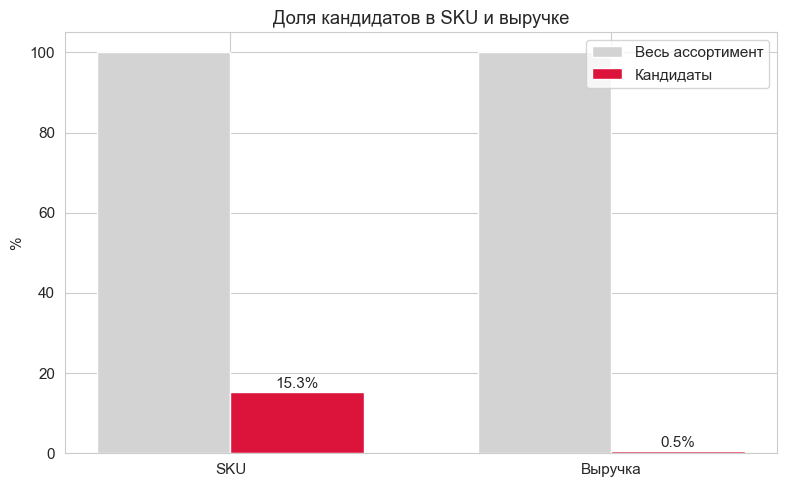

In [35]:
effect = pd.DataFrame({
    'Показатель': [
        'Всего SKU',
        'Кандидатов на вывод',
        'Доля SKU-кандидатов, %',
        'Общая выручка, £',
        'Выручка кандидатов, £',
        'Доля выручки кандидатов, %',
        'Средняя выручка кандидата, £',
        'Средняя выручка остальных SKU, £',
    ],
    'Значение': [
        total_sku,
        cand_sku,
        round(cand_sku / total_sku * 100, 1),
        round(total_rev, 2),
        round(cand_rev, 2),
        round(cand_rev / total_rev * 100, 2),
        round(cand_rev / cand_sku, 2),
        round((total_rev - cand_rev) / (total_sku - cand_sku), 2),
    ]
})
print(effect.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
labels = ['SKU', 'Выручка']
cand_vals = [cand_sku / total_sku * 100, cand_rev / total_rev * 100]
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, [100, 100], width, label='Весь ассортимент', color='lightgray')
ax.bar(x + width/2, cand_vals, width, label='Кандидаты', color='crimson')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('%')
ax.set_title('Доля кандидатов в SKU и выручке')
ax.legend()
for i, v in enumerate(cand_vals):
    ax.text(i + width/2, v + 1, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

| Показатель | Значение |
|------------|----------|
| Всего SKU | 3 988 |
| Кандидатов на вывод | **611 (15.3%)** |
| Общая выручка | £12 156 868 |
| Выручка кандидатов | £62 774 |
| **Доля выручки кандидатов** | **0.52%** |
| Средняя выручка кандидата | £102.74 |
| Средняя выручка остальных SKU | £3 581.31 |

Из них:

- **Основные кандидаты** (надёжные данные о клиентах, ≥ 50% выручки с известным `Customer ID`): **473 SKU**, выручка **£51 137**.
- **На отдельную проверку** (низкое покрытие клиентских данных < 50%): **138 SKU**, выручка **£11 637**.

**Формулировка для бизнеса:**

> «Предлагается проверить на вывод **15.3% SKU**. На них приходится **0.52% исторической выручки**. Из списка исключены новинки (последние 3 месяца), товары с широкой клиентской базой (≥20 покупателей), позиции с длинной историей продаж (≥10 активных месяцев), товары, которые хотя бы раз за период попадали в ABC-категорию A или B, а также SKU с недостаточным покрытием данных о клиентах (вынесены в отдельный список для ручной проверки).»

**Что это НЕ значит:**

- 0.52% — **не гарантированная потеря выручки**. Часть покупателей переключится на аналогичные товары.
- Возможно, часть низких продаж - следствие out-of-stock, а не отсутствия интереса.
- Без данных о марже нельзя утверждать, что сокращение увеличит прибыль.
- Возвраты по кандидатам отрицательные (см. блок «Анализ возвратов»), поэтому вывод этих SKU может даже улучшить структуру движения единиц.

</div>

## Анализ возвратов

In [36]:
df_returns = df_raw.copy()
df_returns['StockCode'] = df_returns['StockCode'].astype(str).str.strip().str.upper()

df_returns['Revenue'] = df_returns['Quantity'] * df_returns['Price']

returns_df = df_returns[
    df_returns['Invoice'].astype(str).str.startswith('C')
].copy()

returns_by_sku = returns_df.groupby('StockCode').agg(
    ReturnedQuantity=('Quantity', 'sum'),
    ReturnedRevenue=('Revenue', 'sum'),
)

matrix_with_returns = matrix.merge(
    returns_by_sku, left_on='StockCode', right_index=True, how='left'
)
matrix_with_returns[['ReturnedQuantity', 'ReturnedRevenue']] = \
    matrix_with_returns[['ReturnedQuantity', 'ReturnedRevenue']].fillna(0)

matrix_with_returns['ReturnRate'] = (
    -matrix_with_returns['ReturnedQuantity'] / matrix_with_returns['Quantity']
)
matrix_with_returns['ReturnRate'] = (
    matrix_with_returns['ReturnRate'].fillna(0).replace([np.inf, -np.inf], 0)
)

print("ТОП-10 SKU по сумме возвратов (в единицах):")
print(matrix_with_returns.nlargest(10, 'ReturnedQuantity')[
    ['StockCode', 'Description', 'ReturnedQuantity', 'ReturnedRevenue', 'ReturnRate']
].to_string(index=False))

candidates_with_returns = matrix_with_returns[
    matrix_with_returns['StockCode'].isin(candidates['StockCode'])
]
total_candidate_returns = candidates_with_returns['ReturnedRevenue'].sum()
print(f"\nОбщая сумма возвратов по всем кандидатам: £{total_candidate_returns:,.2f}")
print(f"Средний ReturnRate по кандидатам: "
      f"{candidates_with_returns['ReturnRate'].mean()*100:.2f}%")

ТОП-10 SKU по сумме возвратов (в единицах):
StockCode                       Description  ReturnedQuantity  ReturnedRevenue  ReturnRate
    22740                     POLKA DOT PEN              0.00             0.00       -0.00
    23439        HAND WARMER RED LOVE HEART              0.00             0.00       -0.00
    62018                         SOMBRERO               0.00             0.00       -0.00
    23134   LARGE ZINC HEART WALL ORGANISER              0.00             0.00       -0.00
    22783  SET 3 WICKER OVAL BASKETS W LIDS              0.00             0.00       -0.00
    23571     TRADITIONAL NAUGHTS & CROSSES              0.00             0.00       -0.00
    21488 RED WHITE SCARF  HOT WATER BOTTLE              0.00             0.00       -0.00
    16014       SMALL CHINESE STYLE SCISSOR              0.00             0.00       -0.00
    23135   SMALL ZINC HEART WALL ORGANISER              0.00             0.00       -0.00
    22687         DOORMAT CHRISTMAS VILLAGE   

<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

**ТОП-10 SKU по объёму возвратов** показывает, что почти все возвраты в анализируемом периоде это товары **не из списка кандидатов**.

| Показатель | Значение |
|------------|----------|
| Общая сумма возвратов по всем кандидатам | **£ −11 433.00** |
| Средний ReturnRate по кандидатам | **154.67%** |

**Как интерпретировать цифры:**

1. **Отрицательная сумма возвратов по кандидатам** означает, что за период было возвращено больше, чем продано, либо по этим SKU возвраты шли после того, как продажи прекратились. Фактически эти товары уже работают «в минус» по движению единиц. Это усиливает аргумент за их вывод, но требует ручной проверки на предмет разовых крупных возвратов.

2. **Средний ReturnRate 154.67%** - это артефакт деления: у некоторых кандидатов возвратов по количеству больше, чем продаж (например, крупный B2B-возврат от товара, который после этого больше не продавался). Такой показатель нельзя читать как «средний процент возврата»: он искажён за счёт малых знаменателей. Для бизнес-решений надёжнее смотреть на абсолютные суммы возвратов и на медиану, а не на среднее.

3. **Ключевой вывод:** наличие отрицательной выручки по кандидатам — дополнительное обоснование их вывода. Но **одновременно** это значит, что если такие SKU всё-таки оставить, бизнесу стоит разобраться в причине возвратов: возможно, часть возвратов связана с качеством товара, а не со спросом.

**Ограничение:** мы не связывали конкретный возврат с исходной продажей только агрегировали по SKU. Поэтому ReturnRate это грубая оценка, а не точный показатель цикла «продажа → возврат».

</div>

## Проверка устойчивости и ограничения

In [37]:
print('ПРОВЕРКА УСТОЙЧИВОСТИ ФИНАЛЬНОГО РЕШЕНИЯ')

def get_candidates_with_cv_thresholds(cv_x, cv_y, use_stable_c=True):
    xyz_temp = xyz.copy()
    xyz_temp['XYZ_temp'] = xyz_temp['CV'].apply(
        lambda c: 'X' if pd.notna(c) and c <= cv_x
        else ('Y' if pd.notna(c) and c <= cv_y else 'Z')
    )

    matrix_temp = matrix.copy()
    matrix_temp = matrix_temp.merge(
        xyz_temp[['XYZ_temp']], left_on='StockCode', right_index=True, how='left'
    )
    matrix_temp['ABC_XYZ_temp'] = matrix_temp['ABC'] + matrix_temp['XYZ_temp']

    mask = (
        (matrix_temp['ABC_XYZ_temp'].isin(['CZ', 'BZ'])) &
        (matrix_temp['Customers'].fillna(0) < 20) &
        (matrix_temp['ActiveMonths'] < 10) &
        (matrix_temp['AvgPrice'] <= 10) &
        (~matrix_temp['IsNew']) &
        (matrix_temp['CustomerRevenueCoverage'] >= 0.5)
    )
    if use_stable_c:
        mask &= matrix_temp['StockCode'].isin(stable_c_skus)

    return matrix_temp[mask].copy()

base_candidates = get_candidates_with_cv_thresholds(0.5, 1.0, use_stable_c=True)
base_skus = set(base_candidates['StockCode'])

print(f"Базовый вариант (CV 0.5/1.0, StableC): "
      f"{len(base_candidates)} SKU, £{base_candidates['Revenue'].sum():,.2f} выручки\n")

for cv_x, cv_y in [(0.4, 0.8), (0.6, 1.2)]:
    alt_candidates = get_candidates_with_cv_thresholds(cv_x, cv_y, use_stable_c=True)
    alt_skus = set(alt_candidates['StockCode'])

    common_skus = len(base_skus & alt_skus)
    only_base = len(base_skus - alt_skus)
    only_alt = len(alt_skus - base_skus)

    print(f"Вариант (CV {cv_x}/{cv_y}, StableC):")
    print(f"  - Кандидатов: {len(alt_candidates)} SKU")
    print(f"  - Выручка: £{alt_candidates['Revenue'].sum():,.2f}")
    print(f"  - Пересечение с базовым: {common_skus} SKU "
          f"({common_skus/len(base_skus)*100:.1f}% от базового)")
    print(f"  - Только в базовом: {only_base} SKU")
    print(f"  - Только в альтернативном: {only_alt} SKU")
    print()

ПРОВЕРКА УСТОЙЧИВОСТИ ФИНАЛЬНОГО РЕШЕНИЯ
Базовый вариант (CV 0.5/1.0, StableC): 473 SKU, £51,136.94 выручки

Вариант (CV 0.4/0.8, StableC):
  - Кандидатов: 476 SKU
  - Выручка: £51,454.84
  - Пересечение с базовым: 473 SKU (100.0% от базового)
  - Только в базовом: 0 SKU
  - Только в альтернативном: 3 SKU

Вариант (CV 0.6/1.2, StableC):
  - Кандидатов: 459 SKU
  - Выручка: £48,640.14
  - Пересечение с базовым: 459 SKU (97.0% от базового)
  - Только в базовом: 14 SKU
  - Только в альтернативном: 0 SKU



<div style="background-color:#f2eff7; padding:15px; border-radius:6px;">

### Вывод по блоку

**Устойчивость финального решения при сдвиге порогов CV** (все фильтры применены одновременно, включая `StableC`):

| Пороги X/Y, Y/Z | Кандидатов, SKU | Выручка, £ | Пересечение с базовым | Только в базовом | Только в альт. |
|-----------------|-----------------|-----------|----------------------|------------------|----------------|
| **0.4 / 0.8** | 476 | 51 455 | 473 (100.0%) | 0 | 3 |
| **0.5 / 1.0 (базовые)** | **473** | **51 137** | — | — | — |
| **0.6 / 1.2** | 459 | 48 640 | 459 (97.0%) | 14 | 0 |

**Что это значит:**

- **Состав кандидатов устойчив.** При сдвиге порогов на ±0.1 ядро списка сохраняется: 100% базового списка совпадает с более мягкими порогами и 97% с более строгими.
- **Сдвиг на 0.1 меняет список на 3-14 SKU** это единицы позиций, а не сотни. Решение не «ломается» от настройки CV.
- **Выручка кандидатов колеблется в диапазоне £48.6K — £51.5K** (≈ 0.40% - 0.42% от общей). Риск от смены порогов минимален.

**Ограничения исследования:**

1. **Нет себестоимости и маржи.** Нельзя утверждать, что удаление низкооборотных SKU повысит прибыль: возможно, часть из них — высокомаржинальные и работают как «трафикообразующие».
2. **Нет остатков и out-of-stock.** Низкие продажи могут быть следствием того, что товар отсутствовал на складе, а не отсутствия спроса.
3. **Нет стоимости хранения и условий поставки.** Оценка «дорого/дёшево держать SKU» не входит в модель.
4. **Данные о возвратах проанализированы на уровне SKU**, но не связаны с конкретными исходными покупками. Это позволяет оценить общую долю возвратов для товара, но не даёт возможности точно сопоставить каждый возврат с первоначальной продажей.
5. **Нет данных о связях SKU в корзине.** Товары-«basket drivers» (которые сами плохо продаются, но тянут другие позиции) могут быть ошибочно отнесены к кандидатам на вывод.
6. **Исторические продажи — не истинный спрос.** Отсутствие данных о нереализованном спросе (просмотры, корзины без покупки) ограничивает выводы.
7. **Нужен пилотный тест** с мониторингом каннибализации (переключение покупателей на аналоги) и оттока клиентов.

</div>

## Итоговые выводы

In [38]:
conclusions = f"""
   - SKU: {total_sku:,}
   - Заказов: {df['Invoice'].nunique():,}
   - Выручка: £{total_rev:,.2f}
   - Средний чек: £{order_revenue.mean():,.2f}

ABC-распределение:
{abc_summary.to_string(index=False)}

XYZ-распределение (с нулевыми месяцами):
{xyz['XYZ'].value_counts().to_string()}

Кандидаты на вывод: {cand_sku} SKU ({cand_sku/total_sku*100:.1f}%),
на них приходится {cand_rev/total_rev*100:.2f}% исторической выручки.
"""
print(conclusions)


   - SKU: 3,988
   - Заказов: 23,920
   - Выручка: £12,156,867.71
   - Средний чек: £508.23

ABC-распределение:
ABC  SKU      Revenue  SKU_share  Revenue_share
  A  862 9,724,480.86       0.22           0.80
  B  994 1,823,607.41       0.25           0.15
  C 2132   608,779.44       0.53           0.05

XYZ-распределение (с нулевыми месяцами):
XYZ
Z    2806
Y    1069
X     113

Кандидаты на вывод: 611 SKU (15.3%),
на них приходится 0.52% исторической выручки.



<div style="background-color:#fdf6e3; padding:15px; border-radius:6px; border-left:4px solid #e8c97a;">

**Период:** 2010-10-01 — 2011-11-30, 14 полных месяцев, 4 полных квартала.

**Масштаб:** 3 988 SKU, 23 920 заказов, £12.16M выручки, средний чек £508.23.

**Структура ассортимента:**

- **A-блок (22% SKU) → 80% выручки** основа бизнеса, нужен контроль наличия.
- **CZ — 46% SKU → 4% выручки** самый крупный пул для проверки.
- **70% SKU в Z-категории** по CV из-за сезонности и учёта нулевых месяцев.
- **За период 27.3% SKU сменили ABC-категорию**, ассортимент подвижен, статический ABC без динамики вводит в заблуждение.

**Стратегия управления по группам:**

| Группа | Стратегия |
|--------|-----------|
| **AX** | Приоритет наличия, минимизация дефицита. 2% SKU дают 12% выручки — это ядро стабильных продаж. |
| **AY** | Гибкое планирование с учётом сезонности. Самый крупный вклад в выручку (41%), нельзя допускать out-of-stock в пиковые месяцы. |
| **AZ** | Закупка под спрос, осторожный запас. 27% выручки при высокой вариативности — есть риск кассовых разрывов и списаний. |
| **BX / BY** | Стандартное управление. Устойчивый средний сегмент, плановый пересмотр раз в квартал. |
| **BZ** | Ограниченный запас, периодический пересмотр. |
| **CX** | Не удалять. Всего 5 SKU с низкой, но стабильной выручкой — проверить роль в корзине. |
| **CY** | Проверить дополнительные метрики (маржа, связность, отзывы) перед любым решением. |
| **CZ** | Основной пул для проверки на вывод, но только устойчивые C-истории и после применения всех фильтров. |

**Решение (Альтернативный вариант):** **611 SKU (15.3%) на вывод, 0.52% исторической выручки.**

Из них:
- **Основные кандидаты (473 SKU, £51 137)** — можно выводить сразу.
- **На отдельную проверку (138 SKU, £11 637)** — низкое покрытие клиентских данных, требуется ручной анализ.

**Рискованный вариант (базовый):** если бизнес готов к более решительным действиям, список из **970 SKU (24.3%) с 0.89% выручки**. Он ближе к ориентиру 20%, но требует дополнительной ручной проверки SKU, отсеянных фильтром `StableC` (349 позиций).

**Что усиливает альтернативный вариант:**

- Динамический ABC по кварталам показывает миграцию SKU между A/B/C (27.3% SKU меняют категорию за период).
- Фильтр `StableC` отсеивает товары, которые хоть раз за период «выстреливали» в A или B.
- Новинки, сезонные товары (514 SKU в пересечении `StableC` и сезонности), позиции с широкой клиентской базой и SKU с недостатком данных о клиентах исключены или вынесены в отдельный список.
- Возвраты по кандидатам отрицательные (£ −11 433) — вывод этих SKU улучшит структуру движения единиц.

**Возможные действия далее:**

1. Ручная проверка группы «на отдельную проверку» (138 SKU) и пересечения «StableC ∩ сезонность» (514 SKU).
2. Пилотное снятие ~5% SKU с мониторингом выручки и оттока.
3. Сравнение двух вариантов на пилоте: базовый (970 SKU) vs альтернативный (611 SKU).
4. Добавление данных о марже, остатках и связях в корзине для уточнения решения.

</div>

Выполнил Лосевский Дмитрий